In [32]:
# import for creating MLP classifier of test set of the UCI ML hand-written digits datasets
'''
Classes            10
Samples per class  ~180
Samples total      1797
Dimensionality     64 (8x8)
Features integers  0-16
'''
import numpy as np
import matplotlib.pylab as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [34]:
# load and examine data, y is the target, with values 0-9, X is set of images
data = load_digits()
X = data.data; y = data.target
print('data shape:',X.shape, y.shape)

data shape: (1797, 64) (1797,)


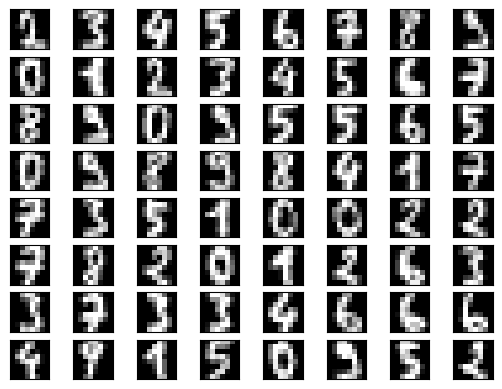

In [36]:
# display nm example images in n x m grid, starting with firstExample image
firstExample = 12
n=8; m=8
fig, ax = plt.subplots(n,m)
ax_flatten = ax.flatten()
for axs,frame in zip(ax_flatten,X[firstExample:firstExample+n*m]):
    axs.imshow(frame.reshape((8,8)),cmap='gray',interpolation='nearest')
    axs.set_xticks([])
    axs.set_yticks([])
        

In [38]:
# now split into test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)
print('training set',X_train.shape, y_train.shape)
print('test set',X_test.shape, y_test.shape)

training set (1437, 64) (1437,)
test set (360, 64) (360,)


In [40]:
# create and apply MLP
hiddenLayerSizes = (19)
activ = 'relu'
solv = 'lbfgs'
randomState = 12
maxIter = 800
#
mlpc = MLPClassifier( hidden_layer_sizes = hiddenLayerSizes, \
                        activation = activ, \
                        solver = solv, \
                        random_state = randomState, \
                        max_iter = maxIter
                    )
mlpc.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=19, max_iter=800, random_state=12,
              solver='lbfgs')

In [42]:
# try prediction on the training and test sets 
predictions = {}  # create dictionary with predictions
for X_split, label in [[X_train,'training'], [X_test,'test']]:
    predictions[label] = mlpc.predict(X_split)
#predictions

In [82]:
# evaluate with metrics
CM={}
for y_split, label in [[y_train,'training'], [y_test,'test']]:
    CM[label] = confusion_matrix(y_split, predictions[label])
    print(label+' data - confusion matrix')
    print(CM[label])

training data - confusion matrix
[[131   0   0   0   0   0   0   0   0   0]
 [  0 147   0   0   0   0   0   0   0   0]
 [  0   0 146   0   0   0   0   0   0   0]
 [  0   0   0 143   0   0   0   0   0   0]
 [  0   0   0   0 137   0   0   0   0   0]
 [  0   0   0   0   0 144   0   0   0   0]
 [  0   0   0   0   0   0 156   0   0   0]
 [  0   0   0   0   0   0   0 137   0   0]
 [  0   0   0   0   0   0   0   0 145   0]
 [  0   0   0   0   0   0   0   0   0 151]]
test data - confusion matrix
[[47  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  1  0]
 [ 0  0 31  0  0  0  0  0  0  0]
 [ 0  0  0 40  0  0  0  0  0  0]
 [ 0  2  0  0 40  0  0  1  1  0]
 [ 0  1  0  0  0 33  0  1  0  3]
 [ 1  1  0  0  0  0 23  0  0  0]
 [ 0  0  0  0  0  0  0 42  0  0]
 [ 0  2  0  0  0  0  0  0 27  0]
 [ 0  0  0  0  1  1  0  1  1 25]]


In [80]:
# determine recall and precision for model

rScore=recall_score(y_test,predictions['test'],average=None)
pScore=precision_score(y_test,predictions['test'],average=None)

print('recall    :', rScore)
print('precision :', pScore)

recall    : [1.         0.97142857 1.         1.         0.90909091 0.86842105
 0.92       1.         0.93103448 0.86206897]
precision : [0.97916667 0.85       1.         1.         0.97560976 0.97058824
 1.         0.93333333 0.9        0.89285714]
